# Notebook 03 — Misallocation Analysis and Country-Level Ranking

This notebook converts the country-year misallocation scores produced in Notebook 02 into
the analytical outputs that drive the Streamlit application: a country-level ranking of
underfunding computed *within income tier*, a residual pattern analysis by region, income
group, and year, and a quartile-based country grouping.

The scored panel is loaded from `data/processed/model_scored.csv`, where the misallocation
score is the residual from the final size-controlled, year-fixed-effects model. A negative
score indicates a country-year that received less adaptation aid than comparable countries in the same year; a positive score indicates more.

## Step 1 — Load the scored panel and verify the carry-over from Notebook 02

Before any aggregation, the scored panel is loaded and checked against the documented output
of Notebook 02. The verification confirms the expected coverage (roughly 1,806 in-sample
country-years across 138 countries), the presence of the model output columns
(`misallocation_score`, `predicted_log_aid`, `funding_vuln_ratio`), and that the misallocation
score behaves as an ordinary-least-squares residual, with a mean near zero. Rows lacking a
score correspond to the listwise-deleted observations and are expected.

In [28]:
import pandas as pd
import numpy as np
from pathlib import Path

# Walk up from the working directory to find the repo root, then the data file.
def locate(filename="model_scored.csv"):
    here = Path.cwd()
    for base in [here, *here.parents]:
        hit = base / "data" / "processed" / filename
        if hit.exists():
            return hit
        # fallback: search anywhere under this base
        found = list(base.glob(f"**/{filename}"))
        if found:
            return found[0]
    return None

SCORED_PATH = locate("model_scored.csv")
print("Working dir:", Path.cwd())
print("Resolved path:", SCORED_PATH)

assert SCORED_PATH is not None, (
    "model_scored.csv not found. Either it was not written by Notebook 02, "
    "or it lives outside the repo. Run the cell below to diagnose."
)
scored = pd.read_csv(SCORED_PATH)

print("="*60); print("SHAPE & COLUMNS"); print("="*60)
print(f"Rows: {len(scored):,}   Columns: {scored.shape[1]}\n")
print(scored.dtypes.to_string()); print()

# Resolve key columns defensively (exact names confirmed from output below)
def find(cands):
    return next((c for c in cands if c in scored.columns), None)
col_iso   = find(["iso3","ISO3","iso_code","country_code"])
col_name  = find(["country","recipient_name","name","country_name","Recipient"])
col_year  = find(["year","Year","TIME_PERIOD"])
col_inc   = find(["income_group","income_grp","income","INCOME_GROUP"])
col_score = find(["misallocation_score","residual","resid"])
col_pred  = find(["predicted_log_aid","yhat","fitted"])
col_ratio = find(["funding_vuln_ratio","aid_vuln_ratio"])

print("="*60); print("KEY COLUMNS RESOLVED"); print("="*60)
for label, c in [("iso3", col_iso), ("country name", col_name), ("year", col_year),
                 ("income_group", col_inc), ("misallocation_score", col_score),
                 ("predicted_log_aid", col_pred), ("funding_vuln_ratio", col_ratio)]:
    print(f"  {label:24s} -> {c if c else '*** NOT FOUND ***'}")
print()

print("="*60); print("COVERAGE"); print("="*60)
if col_iso:  print(f"Unique countries: {scored[col_iso].nunique()}")
if col_year: print(f"Year range: {int(scored[col_year].min())}–{int(scored[col_year].max())}")
if col_score:
    print(f"Rows WITH a misallocation score (in-sample): {scored[col_score].notna().sum():,}")
    print(f"Rows WITHOUT (dropped / listwise-deleted):  {scored[col_score].isna().sum():,}")
    if col_iso:
        print(f"Countries with >=1 scored year: {scored.loc[scored[col_score].notna(), col_iso].nunique()}")
print()

print("="*60); print("MISALLOCATION SCORE DISTRIBUTION (in-sample)"); print("="*60)
if col_score:
    s = scored[col_score].dropna()
    print(s.describe().to_string())
    print(f"\nMean should be ~0 (OLS residuals): {s.mean():+.4f}")
if col_inc:
    print("\nIncome-group row counts:")
    print(scored[col_inc].value_counts(dropna=False).to_string())

Working dir: /Users/sanjogkadayat/climate_adaptation_capstone/notebooks
Resolved path: /Users/sanjogkadayat/climate_adaptation_capstone/data/processed/model_scored.csv
SHAPE & COLUMNS
Rows: 1,806   Columns: 18

iso3                        str
country                     str
year                      int64
adaptation_aid_usd_m    float64
vulnerability           float64
gain_score              float64
gdp_per_capita_usd      float64
gov_effectiveness       float64
income_group                str
is_landlocked             int64
is_sids                   int64
funding_vuln_ratio      float64
log_aid                 float64
log_gdp                 float64
population                int64
log_population          float64
predicted_log_aid       float64
misallocation_score     float64

KEY COLUMNS RESOLVED
  iso3                     -> iso3
  country name             -> country
  year                     -> year
  income_group             -> income_group
  misallocation_score      -> misallocat

## Step 2 — Aggregate country-year scores to a country-level measure

The misallocation score is a country-year residual, but the project's deliverables (ranking,
choropleth, and policy briefs) operate at the country level. Each country's scores are therefore
collapsed to a single value by taking the mean residual across its in-sample years. Averaging is
the appropriate aggregator: Notebook 02 established a mean absolute error of approximately one log
unit, so individual country-year scores are noisy, and the mean across roughly thirteen years
suppresses that noise into a stable country-level signal. The standard deviation across years is
retained as a measure of each country's volatility.

A single income tier is also assigned to each country for the within-tier ranking that follows.
Because a country's income classification can change across the panel through graduation, the most
recent observed classification is used, reflecting current ODA-eligibility status. The number of
countries whose tier changed between 2010 and 2023 is reported so the sensitivity of the grouping
to this choice remains transparent.

In [29]:
# Column names confirmed in Step 1
ISO, NAME, YEAR, INC, SCORE = "iso3", "country", "year", "income_group", "misallocation_score"

# --- Collapse country-year scores to one row per country ---
country = scored.groupby([ISO, NAME], as_index=False).agg(
    n_years            = (SCORE, "size"),
    misallocation_mean = (SCORE, "mean"),
    misallocation_std  = (SCORE, "std"),
    vulnerability_mean = ("vulnerability", "mean"),
    aid_usd_m_mean     = ("adaptation_aid_usd_m", "mean"),
    gdp_pc_mean        = ("gdp_per_capita_usd", "mean"),
    gov_eff_mean       = ("gov_effectiveness", "mean"),
    funding_vuln_ratio_mean = ("funding_vuln_ratio", "mean"),
)

# --- Tier label = MODAL income group (tie-break: most-recent among tied) ---
def assign_modal(g):
    vc = g[INC].value_counts()
    tied = set(vc[vc == vc.max()].index)
    if len(tied) == 1:
        return vc.index[0]
    for t in reversed(list(g.sort_values(YEAR)[INC])):   # walk back to most-recent tied tier
        if t in tied:
            return t

modal_tier  = (scored.groupby(ISO).apply(assign_modal, include_groups=False)
                     .rename("income_tier"))
recent_tier = (scored.sort_values(YEAR).groupby(ISO)[INC].last()
                     .rename("income_tier_recent"))
country = country.merge(modal_tier,  on=ISO, how="left")
country = country.merge(recent_tier, on=ISO, how="left")

# --- Transparency: how often the two rules disagree ---
n_diff = int((country["income_tier"] != country["income_tier_recent"]).sum())
print(f"Tier label differs (modal vs most-recent) for {n_diff} of {len(country)} countries\n")

# --- Sanity report ---
print(f"Countries: {len(country)}   (expect 138)")
print(f"Year-rows accounted for: {country['n_years'].sum():,}   (expect 1,806)\n")
print("Countries by income tier (MODAL):")
print(country["income_tier"].value_counts().to_string())
print("\nmisallocation_mean summary:")
print(country["misallocation_mean"].describe().round(3).to_string())

Tier label differs (modal vs most-recent) for 21 of 138 countries

Countries: 138   (expect 138)
Year-rows accounted for: 1,806   (expect 1,806)

Countries by income tier (MODAL):
income_tier
UM    54
LM    49
L     27
H      8

misallocation_mean summary:
count    138.000
mean      -0.046
std        0.913
min       -2.301
25%       -0.645
50%        0.023
75%        0.558
max        1.826


## Step 3 — Within-income-tier ranking of underfunding

Countries are ranked by their mean misallocation score separately within each income tier, so that
each country is compared against its eligibility peers rather than across the full sample. A rank of
1 within a tier denotes the most underfunded country in that tier, that is, the most negative mean
residual. This within-tier framing is the resolution adopted in Notebook 02 for the eligibility and
strategic-allocation contamination that distorts cross-sample comparison: the upper-middle and high
income tiers contain self-financing economies such as China and geopolitically driven recipients
such as Türkiye and Iraq, for which the question of whether adaptation aid is reaching them is not
the central concern.

The Low and Lower-middle income tiers, which hold the vulnerable and aid-dependent countries the
analysis targets, are reported as the clean headline ranking. The Upper-middle and High income tiers
are reported separately under the graduation and strategic-allocation caveat, with the understanding
that the meaningful signal within them is the genuinely vulnerable states rather than the large or
strategically funded outliers.

In [30]:
# --- Rank within each income tier (1 = most underfunded = most negative mean residual) ---
country = country.sort_values(["income_tier", "misallocation_mean"]).reset_index(drop=True)
grp = country.groupby("income_tier")["misallocation_mean"]
country["tier_rank"] = grp.rank(method="min", ascending=True).astype(int)
country["tier_n"]    = grp.transform("size").astype(int)
country["tier_pct"]  = grp.rank(pct=True, ascending=True).round(3)   # 0 = most underfunded in tier

TIER_LABEL = {"L":"Low income", "LM":"Lower-middle income",
              "UM":"Upper-middle income", "H":"High income"}

def show_tier(tier, n):
    sub = country[country.income_tier == tier].nsmallest(n, "misallocation_mean")
    cols = ["tier_rank","country","misallocation_mean","vulnerability_mean",
            "aid_usd_m_mean","gdp_pc_mean","gov_eff_mean"]
    total = int((country.income_tier == tier).sum())
    print(f"\n--- MOST UNDERFUNDED — {TIER_LABEL[tier]} (showing {min(n,total)} of {total}) ---")
    print(sub[cols].round(3).to_string(index=False))

print("="*70)
print("HEADLINE TIERS — ODA-priority, clean signal")
print("="*70)
for t in ["L", "LM"]:
    show_tier(t, n=15)

print("\n" + "="*70)
print("REPORTED SEPARATELY — graduation / strategic-allocation caveat")
print("="*70)
for t in ["UM", "H"]:
    show_tier(t, n=10)

HEADLINE TIERS — ODA-priority, clean signal

--- MOST UNDERFUNDED — Low income (showing 15 of 27) ---
 tier_rank                  country  misallocation_mean  vulnerability_mean  aid_usd_m_mean  gdp_pc_mean  gov_eff_mean
         1                  Eritrea              -2.283               0.616           0.688      614.191        27.184
         2                   Gambia              -1.493               0.535          14.048      713.865        40.410
         3                   Guinea              -1.398               0.531          28.453      931.226        32.934
         4            Guinea-Bissau              -1.332               0.628          11.726      759.579        25.521
         5 Central African Republic              -1.267               0.582          14.502      452.737        21.353
         6             Sierra Leone              -0.960               0.598          33.960      874.721        30.995
         7                  Burundi              -0.527          

### Step 3a — Thin-data flag on the headline ranking

Because the panel uses listwise deletion, a few fragile states retain only a handful of in-sample
years, so their country-mean misallocation score rests on thin data and the rank should be read with
caution. The headline tiers are screened for countries with fewer than five in-sample years and a
flag is added to the country table. Eritrea, the most underfunded Low income country, is the
principal case: its mean is computed over only the years preceding its multi-year GDP-per-capita gap,
and its peg-overstated GDP would compress the residual, so its true underfunding is more likely
understated than overstated. The finding is retained under the data-gap caveat rather than dropped.

In [31]:
THIN = 5
country["thin_data"] = country["n_years"] < THIN

flagged = (country[country.income_tier.isin(["L","LM"]) & country.thin_data]
           .sort_values("misallocation_mean"))
print(f"Headline-tier countries with < {THIN} in-sample years (rank rests on thin data):")
print("  none" if flagged.empty else
      flagged[["income_tier","tier_rank","country","misallocation_mean","n_years"]].to_string(index=False))

Headline-tier countries with < 5 in-sample years (rank rests on thin data):
income_tier  tier_rank country  misallocation_mean  n_years
          L          1 Eritrea           -2.283179        2


## Step 4 — Residual pattern analysis: region assignment

Region is not present in the scored panel, so each country is assigned a World Bank region, the
standard scheme in climate-finance reporting, for the geographic pattern analysis. The assignment is
derived offline from the United Nations sub-region classification and rolled up to the seven World
Bank regions, with explicit overrides for the South Caucasus and Türkiye, which the United Nations
files under Western Asia but the World Bank assigns to Europe and Central Asia. Region is the one
descriptive cut that is informative about the *level* of misallocation, because, unlike income group
and year, it was not absorbed by a control variable in the Notebook 02 model.

In [32]:
%pip install country_converter -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
import country_converter as coco, logging
logging.getLogger("country_converter").setLevel(logging.ERROR)   # quiet per-country warnings
cc = coco.CountryConverter()

UN_TO_WB = {
    "Eastern Africa":"Sub-Saharan Africa","Middle Africa":"Sub-Saharan Africa",
    "Southern Africa":"Sub-Saharan Africa","Western Africa":"Sub-Saharan Africa",
    "Northern Africa":"Middle East & North Africa","Western Asia":"Middle East & North Africa",
    "Central Asia":"Europe & Central Asia","Eastern Europe":"Europe & Central Asia",
    "Northern Europe":"Europe & Central Asia","Southern Europe":"Europe & Central Asia",
    "Western Europe":"Europe & Central Asia","Southern Asia":"South Asia",
    "Eastern Asia":"East Asia & Pacific","South-eastern Asia":"East Asia & Pacific",
    "Melanesia":"East Asia & Pacific","Micronesia":"East Asia & Pacific","Polynesia":"East Asia & Pacific",
    "Caribbean":"Latin America & Caribbean","Central America":"Latin America & Caribbean",
    "South America":"Latin America & Caribbean","Northern America":"North America",
}
# WB places these in Europe & Central Asia though the UN files them under Western Asia / unmatched
WB_OVERRIDE = {c:"Europe & Central Asia" for c in ["ARM","AZE","GEO","TUR","CYP","XKX","XKO","KSV"]}

un = cc.convert(names=country["iso3"].tolist(), src="ISO3", to="UNregion", not_found=None)
country["region"] = [WB_OVERRIDE.get(i, UN_TO_WB.get(u) if u is not None else None)
                     for i, u in zip(country["iso3"], un)]

unmapped = country[country["region"].isna()]
print(f"Mapped to a WB region: {country['region'].notna().sum()} of {len(country)}")
print("UNMAPPED:", "none" if unmapped.empty else
      "\n" + unmapped[["iso3","country"]].to_string(index=False))
print("\nCountries per region:")
print(country["region"].value_counts().to_string())

Mapped to a WB region: 138 of 138
UNMAPPED: none

Countries per region:
region
Sub-Saharan Africa            46
Latin America & Caribbean     30
East Asia & Pacific           23
Europe & Central Asia         18
Middle East & North Africa    12
South Asia                     9


## Step 4a — Geographic pattern of misallocation

Mean misallocation is summarised by World Bank region. Because region was not a control in the
model, regional means are informative about the level of systematic under- or over-funding that
remains after accounting for vulnerability, income, size, governance, and year. A negative regional
mean indicates that countries in the region receive less adaptation aid than otherwise-comparable
countries elsewhere. The within-tier dispersion of misallocation is also shown: because income-tier
dummies were included in the model, each tier's mean residual is zero by construction, so the
informative quantity within tiers is the spread rather than the level.

                             mean  count
region                                  
Sub-Saharan Africa         -0.296     46
South Asia                 -0.224      9
Latin America & Caribbean   0.013     30
Middle East & North Africa  0.037     12
Europe & Central Asia       0.138     18
East Asia & Pacific         0.261     23


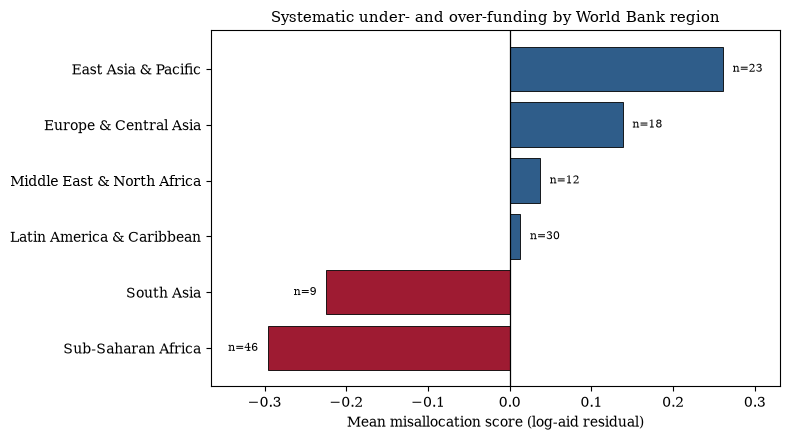

In [34]:
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams["font.family"] = "serif"   # set to "Times New Roman" if installed

# figures directory at repo root
root = Path.cwd()
while root.parent != root and not (root / ".venv").exists():
    root = root.parent
FIG_DIR = root / "figures"; FIG_DIR.mkdir(exist_ok=True)

reg = (country.groupby("region")["misallocation_mean"]
              .agg(["mean", "count"]).sort_values("mean"))
print(reg.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#9e1b32" if v < 0 else "#2f5d8a" for v in reg["mean"]]
ax.barh(reg.index, reg["mean"], color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.9)
pad = 0.07
ax.set_xlim(reg["mean"].min() - pad, reg["mean"].max() + pad)
for i, (v, n) in enumerate(zip(reg["mean"], reg["count"])):
    ax.text(v + (0.012 if v >= 0 else -0.012), i, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax.set_xlabel("Mean misallocation score (log-aid residual)")
ax.set_title("Systematic under- and over-funding by World Bank region", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_region_misallocation.png", dpi=140)
plt.show()

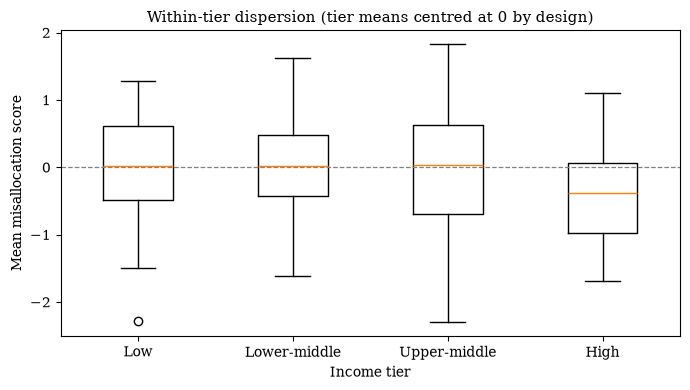

saved: /Users/sanjogkadayat/climate_adaptation_capstone/data/processed/country_scored.csv | rows: 138 | cols: 17


In [35]:
TIER_LABEL = {"L":"Low", "LM":"Lower-middle", "UM":"Upper-middle", "H":"High"}
order = ["L", "LM", "UM", "H"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([country.loc[country.income_tier == t, "misallocation_mean"].values for t in order],
           tick_labels=[TIER_LABEL[t] for t in order])
ax.axhline(0, color="gray", linestyle="--", linewidth=0.9)
ax.set_ylabel("Mean misallocation score"); ax.set_xlabel("Income tier")
ax.set_title("Within-tier dispersion (tier means centred at 0 by design)", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_income_dispersion.png", dpi=140)
plt.show()

# --- Checkpoint: persist the country table (ranking spine + region) ---
OUT = root / "data" / "processed" / "country_scored.csv"
country.to_csv(OUT, index=False)
print("saved:", OUT, "| rows:", len(country), "| cols:", country.shape[1])

## Step 4b — Hypothesis H2: did the Paris Agreement change allocation patterns?

The secondary hypothesis holds that the 2015 Paris Agreement did not meaningfully change how
adaptation aid is allocated relative to vulnerability. Because the model already includes year fixed
effects, this hypothesis cannot be tested from year-level residual means, which are zero by
construction. It is instead tested as a change in the relationship between vulnerability and aid: a
post-2015 indicator is interacted with vulnerability, and the interaction coefficient measures
whether the responsiveness of adaptation aid to vulnerability differs after Paris. The post-2015 main
effect is omitted because it is absorbed by the year fixed effects. The baseline specification from
Notebook 02 is first re-estimated to confirm exact replication (R-squared approximately 0.501,
n = 1,806), after which the interaction is added. A statistically insignificant interaction supports
H2: the vulnerability-aid relationship did not shift after the Paris Agreement.

In [36]:
import statsmodels.formula.api as smf

scored["post2015"] = (scored["year"] >= 2015).astype(int)

base_f = ("log_aid ~ vulnerability + log_gdp + gov_effectiveness + log_population "
          "+ is_landlocked + is_sids + C(income_group, Treatment(reference='L')) + C(year)")
int_f  = ("log_aid ~ vulnerability + vulnerability:post2015 + log_gdp + gov_effectiveness "
          "+ log_population + is_landlocked + is_sids "
          "+ C(income_group, Treatment(reference='L')) + C(year)")

base = smf.ols(base_f, data=scored).fit(cov_type="cluster", cov_kwds={"groups": scored["iso3"]})
intr = smf.ols(int_f,  data=scored).fit(cov_type="cluster", cov_kwds={"groups": scored["iso3"]})

print(f"Baseline replication: n={int(base.nobs)}, R2={base.rsquared:.3f}  (expect ~0.501, n=1806)")
print(f"Interaction model:    n={int(intr.nobs)}, R2={intr.rsquared:.3f}\n")

for term in ["vulnerability", "vulnerability:post2015"]:
    print(f"  {term:26s} b={intr.params[term]:+.4f}  SE={intr.bse[term]:.4f}  "
          f"p={intr.pvalues[term]:.4f}")

slope_pre  = intr.params["vulnerability"]
slope_post = intr.params["vulnerability"] + intr.params["vulnerability:post2015"]
p_int      = intr.pvalues["vulnerability:post2015"]
print(f"\nImplied vulnerability slope  pre-2015: {slope_pre:+.4f}")
print(f"Implied vulnerability slope post-2015: {slope_post:+.4f}")
verdict = "SUPPORTED — no significant post-Paris shift" if p_int >= 0.05 \
          else "NOT supported — significant post-Paris shift"
print(f"\nH2 at alpha=0.05: {verdict}  (interaction p={p_int:.4f})")

Baseline replication: n=1806, R2=0.501  (expect ~0.501, n=1806)
Interaction model:    n=1806, R2=0.502

  vulnerability              b=+2.5965  SE=1.4105  p=0.0657
  vulnerability:post2015     b=+1.5981  SE=0.7448  p=0.0319

Implied vulnerability slope  pre-2015: +2.5965
Implied vulnerability slope post-2015: +4.1946

H2 at alpha=0.05: NOT supported — significant post-Paris shift  (interaction p=0.0319)


### Confirming the post-Paris shift

Because the rejection of H2 reverses the hypothesised direction, two confirmatory tests are run.
First, a linear test evaluates whether the post-2015 vulnerability slope, the sum of the main effect
and the interaction, is itself significantly different from zero. This establishes that adaptation
aid is significantly responsive to vulnerability in the post-Paris period, not merely that the slope
changed. Second, the baseline specification is re-estimated separately on the pre-2015 and post-2015
subsamples as a robustness check; a steeper and more significant vulnerability coefficient in the
post-2015 subsample corroborates the interaction result.

In [37]:
# (1) Is the post-2015 vulnerability slope itself significantly different from zero?
lin = intr.t_test("vulnerability + vulnerability:post2015 = 0")
post_b, post_p = float(lin.effect[0]), float(lin.pvalue)
print(f"(1) Post-2015 vulnerability slope = {post_b:+.4f}, p={post_p:.4f}  "
      f"({'significant' if post_p < 0.05 else 'not significant'} vs zero)\n")

# (2) Split-sample robustness: fit the baseline separately pre/post 2015
print("(2) Split-sample (baseline spec fit separately on each period):")
for label, mask in [("PRE  2010–2014", scored.year < 2015),
                    ("POST 2015–2023", scored.year >= 2015)]:
    sub = scored[mask]
    m = smf.ols(base_f, data=sub).fit(cov_type="cluster", cov_kwds={"groups": sub["iso3"]})
    print(f"   {label}: n={int(m.nobs)}, vulnerability b={m.params['vulnerability']:+.4f}, "
          f"SE={m.bse['vulnerability']:.4f}, p={m.pvalues['vulnerability']:.4f}")

(1) Post-2015 vulnerability slope = +4.1946, p=0.0023  (significant vs zero)

(2) Split-sample (baseline spec fit separately on each period):
   PRE  2010–2014: n=650, vulnerability b=+2.4300, SE=1.4610, p=0.0963
   POST 2015–2023: n=1156, vulnerability b=+4.3220, SE=1.4647, p=0.0032


## Step 5 — Quartile country profiles

Each country is assigned to one of four allocation profiles by quartile of its mean misallocation
score: Chronically Underfunded, Underfunded, Adequately Funded, and Over-Resourced, in order of
increasing aid relative to expectation. Quartiles are computed across the full set of 138 countries
on a single scale. This is consistent with the within-tier framing rather than a departure from it,
because the misallocation score is already net of income tier: the model's income-group dummies
centre each tier, so a country's score expresses deviation from its tier-year expectation, and
quartiling these scores globally compares deviations that are already tier-adjusted. The profile
provides the colour encoding for the choropleth map, while the within-tier rank from Step 3 remains
the basis for the ranking tables. The distribution of profiles across income tiers is examined to
confirm that no single tier dominates a profile, which would indicate residual tier contamination.

In [38]:
PROFILES = ["Chronically Underfunded", "Underfunded", "Adequately Funded", "Over-Resourced"]
country["profile"] = pd.qcut(country["misallocation_mean"], q=4, labels=PROFILES)

edges = pd.qcut(country["misallocation_mean"], q=4, retbins=True)[1]
print("Quartile cutpoints (misallocation_mean):", np.round(edges, 3).tolist())
print("\nCountries per profile:")
print(country["profile"].value_counts()[PROFILES].to_string())

print("\nProfile × income tier (sanity: each profile should span tiers):")
ct = (pd.crosstab(country["profile"], country["income_tier"])
        .reindex(PROFILES)[["L", "LM", "UM", "H"]])
print(ct.to_string())

# --- Checkpoint: re-save the country table with profile column ---
OUT = root / "data" / "processed" / "country_scored.csv"
country.to_csv(OUT, index=False)
print("\nsaved:", OUT, "| rows:", len(country), "| cols:", country.shape[1])

Quartile cutpoints (misallocation_mean): [-2.301, -0.645, 0.023, 0.558, 1.826]

Countries per profile:
profile
Chronically Underfunded    35
Underfunded                34
Adequately Funded          34
Over-Resourced             35

Profile × income tier (sanity: each profile should span tiers):
income_tier              L  LM  UM  H
profile                              
Chronically Underfunded  6  12  14  3
Underfunded              7  12  12  3
Adequately Funded        6  15  12  1
Over-Resourced           8  10  16  1

saved: /Users/sanjogkadayat/climate_adaptation_capstone/data/processed/country_scored.csv | rows: 138 | cols: 18
